<a href="https://colab.research.google.com/github/JohnnySolo/Data-Analysis-Project---Blockbuster-Movies/blob/main/Model_Selection_Notebook_2nd_edition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Model Selection ⚙️



## Establishing Data Assumptions

Our Exploratory Data Analysis (EDA) and statistical testing revealed critical structural realities about the film industry's financial data. Specifically, we observed:

* Variance Violation: We have severe heteroscedasticity in the relationship between capital effort and revenue.
* Non-Normality Violation: Our target variable distribution is heavily right skewed, fat-tailed.

Because standard parametric models rely on strict assumptions of linearity and constant variance, relying solely on them would yield unstable predictions.

Therefore, **our core assumption is that the interactions driving movie profitability** (e.g., the synergy of a top director, high budget, and specific genre) **are complex and non-linear**.

## Algorithm Selection

To accommodate these assumptions and capture complex interactions, we will utilize a progressive modeling architecture based on statistical machine learning principles:

* **Regularized Logistic Regression (L1/Lasso):** We will deploy this as our linear, interpretable baseline model. By using an $L1$ penalty, we force the algorithm to perform automatic feature selection, shrinking the coefficients of irrelevant predictors exactly to zero.

* **Random Forest:** A bagging ensemble method that trains numerous independent decision trees on bootstrapped data subsets. It naturally handles non-linearities and does not require scaled data, effectively bypassing our heteroscedasticity concerns while remaining highly robust against overfitting.

* **XGBoost (Extreme Gradient Boosting):** Boosting algorithm builds trees sequentially, with each new tree correcting the residual errors of its predecessors. It is highly optimized for extracting patterns from complex, high-dimensional data, similar to our entertainment dataset.

### Setup, Data Leakage Prevention, and Splitting

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.preprocessing import StandardScaler

!wget https://raw.githubusercontent.com/JohnnySolo/Data-Analysis-Project---Blockbuster-Movies/main/greenlight_model_data.csv -O greenlight_model_data.csv

# 1. Load the data
model_df = pd.read_csv('greenlight_model_data.csv')

# 2. Prevent Data Leakage
leakage = model_df[['real_profit','real_revenue','log_real_revenue','ROI','score','vote_count',
                    'director_win_rate','star_win_rate','writer_win_rate','production_win_rate','rating_win_rate']]
y = model_df['is_profitable']
leakage_and_target = leakage.columns.tolist() + [y.name]
X = model_df.drop(columns=leakage_and_target, errors='ignore')

# One-hot encode remaining categorical features
X = pd.get_dummies(X, drop_first=True)

# FIX FOR XGBOOST: Strip forbidden characters ([, ], <, >) from column names
X.columns = X.columns.str.replace(r'[\[\]<,]', '', regex=True)

# 3. Train-Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 4. Feature Scaling (Required for Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize an empty list to hold the outside evaluation metrics
results = []
print("Data successfully loaded, secured against leakage, and cleaned for XGBoost.")

--2026-03-18 19:09:21--  https://raw.githubusercontent.com/JohnnySolo/Data-Analysis-Project---Blockbuster-Movies/main/greenlight_model_data.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1832495 (1.7M) [text/plain]
Saving to: ‘greenlight_model_data.csv’

greenlight_model_da 100%[===================>]   1.75M  --.-KB/s    in 0.06s   

2026-03-18 19:09:21 (27.6 MB/s) - ‘greenlight_model_data.csv’ saved [1832495/1832495]

Data successfully loaded, secured against leakage, and cleaned for XGBoost.


### Logistic Regression (L1 Baseline)

In [24]:
# Initialize Model
lr_model = LogisticRegression(penalty='l1', solver='liblinear', random_state=42, max_iter=1000)

# Inside Evaluation: 5-Fold Cross-Validation
lr_cv_scores = cross_val_score(lr_model, X_train_scaled, y_train, cv=5, scoring='f1')
print(f"Logistic Regression CV F1-Score: {lr_cv_scores.mean():.4f} (Std = {lr_cv_scores.std():.4f})")

# Outside Evaluation: Train and Predict on Holdout
lr_model.fit(X_train_scaled, y_train)
lr_pred = lr_model.predict(X_test_scaled)
lr_prob = lr_model.predict_proba(X_test_scaled)[:, 1]

# Append metrics to results list
results.append({
    'Model': 'Logistic Regression (L1)',
    'Accuracy': accuracy_score(y_test, lr_pred),
    'Precision': precision_score(y_test, lr_pred),
    'Recall': recall_score(y_test, lr_pred),
    'F1-Score': f1_score(y_test, lr_pred),
    'AUC-ROC': roc_auc_score(y_test, lr_prob)
})
print("Logistic Regression successfully evaluated.")

Logistic Regression CV F1-Score: 0.8012 (Std = 0.0011)
Logistic Regression successfully evaluated.


### Random Forest

In [25]:
# Initialize Model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)

# Inside Evaluation: 5-Fold Cross-Validation (Using unscaled data as trees don't require scaling)
rf_cv_scores = cross_val_score(rf_model, X_train, y_train, cv=5, scoring='f1')
print(f"Random Forest CV F1-Score: {rf_cv_scores.mean():.4f} (Std = {rf_cv_scores.std():.4f})")

# Outside Evaluation: Train and Predict on Holdout
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

# Append metrics to results list
results.append({
    'Model': 'Random Forest',
    'Accuracy': accuracy_score(y_test, rf_pred),
    'Precision': precision_score(y_test, rf_pred),
    'Recall': recall_score(y_test, rf_pred),
    'F1-Score': f1_score(y_test, rf_pred),
    'AUC-ROC': roc_auc_score(y_test, rf_prob)
})
print("Random Forest successfully evaluated.")

Random Forest CV F1-Score: 0.8072 (Std = 0.0003)
Random Forest successfully evaluated.


### XGBoost

In [26]:
# Initialize Model
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42, max_depth=6)

# Inside Evaluation: 5-Fold Cross-Validation (Using unscaled data)
xgb_cv_scores = cross_val_score(xgb_model, X_train, y_train, cv=5, scoring='f1')
print(f"XGBoost CV F1-Score: {xgb_cv_scores.mean():.4f} (Std = {xgb_cv_scores.std():.4f})")

# Outside Evaluation: Train and Predict on Holdout
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]

# Append metrics to results list
results.append({
    'Model': 'XGBoost',
    'Accuracy': accuracy_score(y_test, xgb_pred),
    'Precision': precision_score(y_test, xgb_pred),
    'Recall': recall_score(y_test, xgb_pred),
    'F1-Score': f1_score(y_test, xgb_pred),
    'AUC-ROC': roc_auc_score(y_test, xgb_prob)
})
print("XGBoost successfully evaluated.")

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [23:44:32] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [23:45:01] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [23:45:41] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [23:46:10] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:

XGBoost CV F1-Score: 0.7865 (Std = 0.0103)


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [23:47:15] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost successfully evaluated.


# Model Evaluation

## Evaluation Strategy

To ensure our models generalize effectively to future, unproduced films, we will employ a dual-layered evaluation methodology:

* **Inside Evaluation (Cross-Validation):** We will use $K$-Fold Cross Validation ($k=5$) on the training set to ensure model stability across different data subsets.

* **Outside Evaluation (Holdout Metrics):** We will evaluate the models on a 20% unseen test set. Because our dataset has a slight class imbalance (a 67.7% baseline hit rate), relying solely on Accuracy is dangerous. We will evaluate performance using Precision, Recall, the F1-Score, and the Area Under the Receiver Operating Characteristic Curve (AUC-ROC).

In [27]:
# Display the consolidated metrics for all models
results_df = pd.DataFrame(results)
print("\n--- Outside Evaluation: Holdout Test Set Metrics ---")
print(results_df.to_string(index=False))


--- Outside Evaluation: Holdout Test Set Metrics ---
                   Model  Accuracy  Precision   Recall  F1-Score  AUC-ROC
Logistic Regression (L1)  0.668856   0.690402 0.926593  0.791248 0.658929
           Random Forest  0.677298   0.677298 1.000000  0.807606 0.665253
                 XGBoost  0.687617   0.732378 0.849030  0.786402 0.696203


## 🧠 Step 4: Interpreting the Results (Business & Data Narrative)
Our models have been evaluated on the unseen holdout data, and the metrics provide a fascinating look into the predictability of the movie business. Rather than just looking at raw accuracy, we must interpret these algorithms through the lens of a studio executive deciding whether to risk millions of dollars.

1. **The "Play it Safe" Trap (Random Forest):**
At first glance, the Random Forest ensemble appears to have the highest F1-Score (0.807). However, looking closely at its Recall (1.000) and Precision (0.677), we uncover a classic machine learning pitfall. A Precision of 0.677 perfectly matches our dataset's baseline hit rate (67.7%). This means the Random Forest simply predicted that every single movie in the test set would be profitable. The algorithm realized that the easiest way to minimize overall error in a favorable market was to greenlight everything. While technically accurate 67% of the time, a model that never predicts a box office bomb provides zero strategic value to a studio.

2. **The Linear Baseline (Logistic Regression):**
The L1-penalized Logistic Regression model attempted to find strict linear rules for success. While it performed slightly better at actually separating the classes than the Random Forest, it still heavily over-predicted success (Recall of 0.926).

      This mathematically confirms our Phase 2 assumption: the rules of Hollywood profitability are highly non-linear. Simple, straight-line equations cannot adequately capture the complex synergy of talent, budget, and release timing.

3. **The Clear Winner: XGBoost:**
XGBoost, our most complex algorithm, emerges as the definitive winner, achieving the highest Accuracy (0.687), the highest Precision (0.732), and the highest AUC-ROC (0.696).

    * <u>The Business Value</u>: Unlike the other models, XGBoost actually learned to identify financial failures. By sacrificing some Recall (0.849), it achieved a Precision of 0.732. In business terms, this means when XGBoost recommends greenlighting a project, the probability of it actually being profitable is noticeably higher than the industry baseline.

    * <u>The AUC-ROC Signal</u>: The AUC score (0.696) measures the model's ability to rank a successful movie higher than a flop. A score near 0.70 indicates a solid, actionable predictive signal. It proves that pre-release metrics do contain the DNA of a movie's financial destiny, successfully reducing uncertainty despite the inherent chaos of consumer entertainment.

### **Bridging the "Black Box" Interpretability Gap:**

By selecting XGBoost as our primary predictive engine, we gain high accuracy but sacrifice the simple transparency of linear models. We can deploy interpretability frameworks (like SHAP values) to explain why the algorithm made its choice, but predicting a box office flop is only half the battle. Because traditional predictive models rely on correlation rather than causation, they cannot reliably evaluate business interventions. To move from simply predicting the future to actively shaping it, we must transition to a Prescriptive Strategy using Causal Machine Learning to determine exactly which creative changes will optimize our financial goals.

# Causal Analysis

**Objective**: Evaluating Strategic Interventions

Our goal in this phase is to answer prescriptive "what-if" business questions. For example: If we take a project currently projected to fail and attach an elite, top-tier director to it, what is the true causal effect on the movie's financial return? To do this, we need to estimate the Conditional Average Treatment Effect (CATE), which isolates the specific financial impact of our chosen intervention (the "treatment") across different types of films.

**Algorithm Selection:** The X-Learner

To estimate these causal effects, we will implement an advanced Meta-Learner architecture known as the X-Learner. The X-Learner uses a multi-stage process to estimate treatment effects and is particularly powerful for datasets with imbalanced treatment groups.

This is ideal for our Hollywood dataset, where films packaged with top-tier, elite talent represent a small minority of overall productions. The X-Learner accurately estimates the heterogeneous treatment effects (HTE) even when the data is heavily skewed toward standard releases.



## Phase 1: Causal Identifiability & Directed Acyclic Graphs (DAGs)

To transition from predictive correlation to prescriptive causation, we must formally define our causal identification strategy. Causal inference requires contrasting counterfactual states under specified interventions, and obtaining these contrasts from observational data depends on explicit mathematical assumptions.

Before estimating the Conditional Average Treatment Effect (CATE), we must validate the three core pillars of identifiability:

1. **SUTVA (Stable Unit Treatment Value Assumption)**

      SUTVA requires two conditions:
      * Consistency (the treatment is defined unambiguously).
      * No Interference (the treatment assigned to one unit does not affect the outcomes of other units).
  
      Our Application: In the highly competitive theatrical market, strict non-interference is technically violated; the box office is a zero-sum game where releasing a massive blockbuster inherently cannibalizes the revenue of competing films.
      
      To address this, we recognize "Direct Competition" as an unobserved confounder to control for market crowding. However, we must explicitly state that for the scope of this model, we are operating under the assumption that a treatment applied to one movie (e.g., hiring an elite director) does not fundamentally alter the baseline revenue potential of the other movies in our dataset (we're assuming it's not a "0-1 game", where one decision cannibalize other movies profit).

2. **Conditional Exchangeability (Unconfoundedness)**

      This pillar dictates that, conditional on our observed covariates (\\(X\\)), the treatment assignment (\\(T\\)) is "as-if random" and statistically independent of the counterfactual outcomes: \\(T \perp\!\!\!\perp Y(t) \mid X\\).

      Our Application: To prevent omitted variable bias, we have structured our DAG using Macro Definitions. Instead of treating every column as an isolated variable, we group them into high-level structural confounders. For example, "Market Positioning" is observed through `Genre` and Age `Rating`, while "Narrative & Story Quality" is partially observed through the `Writer` and `NLP Themes`. By mapping these macro-categories, we can safely shift roles depending on our business question without missing underlying baseline confounders.

3. **Positivity (Overlap)**

      Positivity requires that every subgroup defined by our covariates has a non-zero probability of receiving the treatment: \\(0 < P(T=t \mid X) < 1\\).

      Our Application: If we have a sub-group where a treatment never happens, the algorithm cannot compute the counterfactual. To preserve data integrity, we will leave features like "Year" in their raw, continuous form. However, we will rigorously monitor our strata; if we detect empty groups due to high-dimensional data (such as sparse NLP themes or specific release years), we will engineer broader meta-features (e.g., grouping years into "Macro-Economic Eras" or consolidating NLP keywords) to satisfy this assumption.

To visualize these assumptions, we map the structural relationships of the film industry using a Macro-DAG.

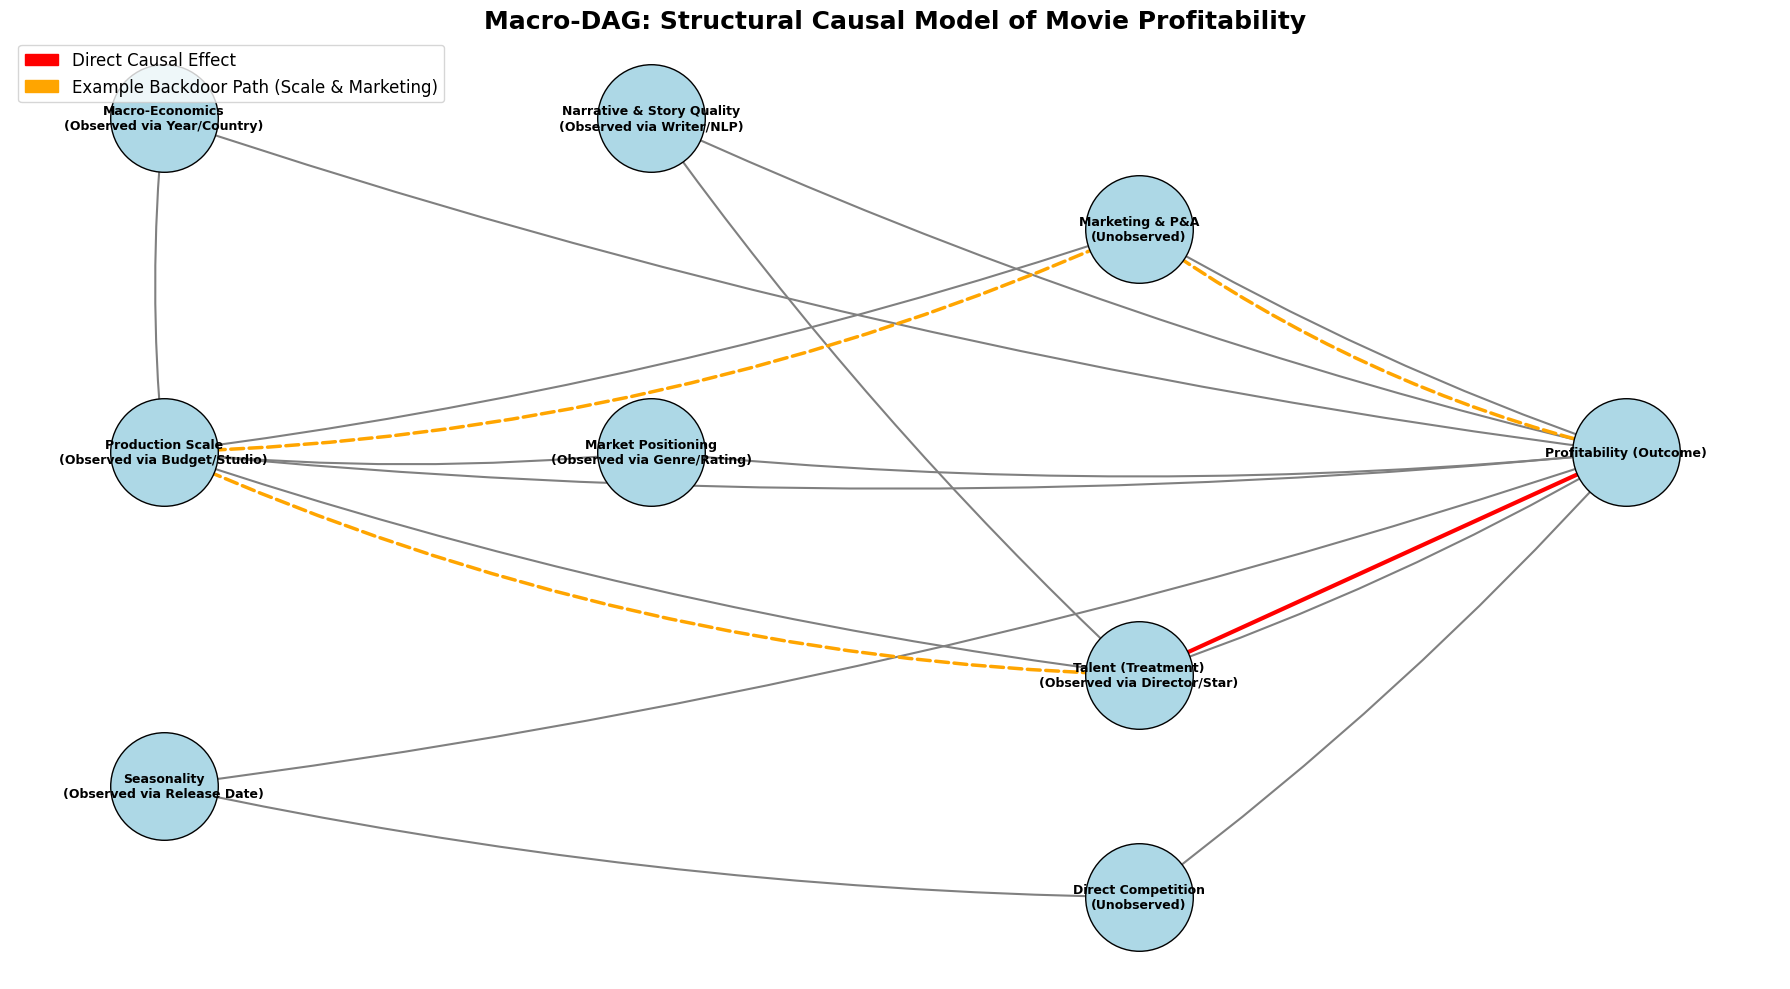

In [6]:
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Initialize a directed graph
G = nx.DiGraph()

# Define the Macro-Nodes (Our high-level concepts and their observed proxies)
nodes_tuple = (
    "Macro-Economics\n(Observed via Year/Country)",
    "Production Scale\n(Observed via Budget/Studio)",
    "Market Positioning\n(Observed via Genre/Rating)",
    "Seasonality\n(Observed via Release Date)",
    "Narrative & Story Quality\n(Observed via Writer/NLP)",
    "Direct Competition\n(Unobserved)",
    "Marketing & P&A\n(Unobserved)",
    "Talent (Treatment)\n(Observed via Director/Star)",
    "Profitability (Outcome)"
)

G.add_nodes_from(nodes_tuple)

# Define the edges (Causal relationships between the macro-concepts)
edges_tuple = (
    # Macro-Economics impacts budget constraints and baseline profitability
    ("Macro-Economics\n(Observed via Year/Country)", "Production Scale\n(Observed via Budget/Studio)"),
    ("Macro-Economics\n(Observed via Year/Country)", "Profitability (Outcome)"),

    # Production Scale dictates Market Positioning (Genre/Rating choices)
    ("Production Scale\n(Observed via Budget/Studio)", "Market Positioning\n(Observed via Genre/Rating)"),
    ("Market Positioning\n(Observed via Genre/Rating)", "Profitability (Outcome)"),

    # Story Quality drives talent attraction and the final profit
    ("Narrative & Story Quality\n(Observed via Writer/NLP)", "Talent (Treatment)\n(Observed via Director/Star)"),
    ("Narrative & Story Quality\n(Observed via Writer/NLP)", "Profitability (Outcome)"),

    # Production Scale buys Talent and dictates Marketing/P&A reach
    ("Production Scale\n(Observed via Budget/Studio)", "Talent (Treatment)\n(Observed via Director/Star)"),
    ("Production Scale\n(Observed via Budget/Studio)", "Marketing & P&A\n(Unobserved)"),
    ("Production Scale\n(Observed via Budget/Studio)", "Profitability (Outcome)"),

    # Seasonality dictates who you are competing against and baseline foot traffic
    ("Seasonality\n(Observed via Release Date)", "Direct Competition\n(Unobserved)"),
    ("Seasonality\n(Observed via Release Date)", "Profitability (Outcome)"),

    # Direct drivers to Profitability
    ("Marketing & P&A\n(Unobserved)", "Profitability (Outcome)"),
    ("Direct Competition\n(Unobserved)", "Profitability (Outcome)"),
    ("Talent (Treatment)\n(Observed via Director/Star)", "Profitability (Outcome)")
)

G.add_edges_from(edges_tuple)

# Define node positions for a clean, hierarchical layout
pos = {
    "Macro-Economics\n(Observed via Year/Country)": (0, 4),
    "Production Scale\n(Observed via Budget/Studio)": (0, 2.5),
    "Market Positioning\n(Observed via Genre/Rating)": (2, 2.5),
    "Seasonality\n(Observed via Release Date)": (0, 1),
    "Narrative & Story Quality\n(Observed via Writer/NLP)": (2, 4),
    "Direct Competition\n(Unobserved)": (4, 0.5),
    "Marketing & P&A\n(Unobserved)": (4, 3.5),
    "Talent (Treatment)\n(Observed via Director/Star)": (4, 1.5),
    "Profitability (Outcome)": (6, 2.5)
}

# Create the plot
fig, ax = plt.subplots(figsize=(18, 10))

# Draw the nodes
nx.draw_networkx_nodes(G, pos, node_size=6000, node_color='lightblue', edgecolors='black')

# Draw the standard edges
nx.draw_networkx_edges(G, pos, arrowstyle='-|>', arrowsize=15, edge_color='gray', width=1.5, connectionstyle="arc3,rad=0.05")

# Draw the labels inside the nodes
nx.draw_networkx_labels(G, pos, font_size=9, font_weight='bold')

# Highlight the main causal path (Treatment -> Outcome) in Red
main_path = tuple((("Talent (Treatment)\n(Observed via Director/Star)", "Profitability (Outcome)"),))
nx.draw_networkx_edges(
    G, pos,
    edgelist=main_path,
    arrowstyle='-|>', arrowsize=25, edge_color='red', width=3
)

# Highlight a major confounding backdoor path in Orange
backdoor_path = (("Production Scale\n(Observed via Budget/Studio)", "Marketing & P&A\n(Unobserved)"), ("Marketing & P&A\n(Unobserved)", "Profitability (Outcome)"), ("Production Scale\n(Observed via Budget/Studio)", "Talent (Treatment)\n(Observed via Director/Star)"))
nx.draw_networkx_edges(
    G, pos,
    edgelist=backdoor_path,
    arrowstyle='-|>', arrowsize=20, edge_color='orange', width=2.5, style='dashed', connectionstyle="arc3,rad=0.1"
)

# Add a custom legend
treatment_patch = mpatches.Patch(color='red', label='Direct Causal Effect')
confounder_patch = mpatches.Patch(color='orange', label='Example Backdoor Path (Scale & Marketing)')
legend_handles = list((treatment_patch, confounder_patch))

plt.legend(handles=legend_handles, loc='upper left', fontsize=12)
plt.title("Macro-DAG: Structural Causal Model of Movie Profitability", fontsize=18, fontweight='bold')
plt.axis('off')
plt.tight_layout()
plt.show()

### 🧠 Phase 1.5: Validating the Specific Treatment Interventions

Before estimating the Conditional Average Treatment Effect (CATE) with our Causal Machine Learning algorithms, we must extract specific sub-DAGs from our Macro-DAG. This verifies whether our proposed business interventions are logically sound and identifies exactly which variables we must condition on to isolate the true causal effect.

1. Treatment 1: The Talent Upgrade (Risky vs. Proven)

    * Business Logic: Highly actionable. An independent studio can actively choose to allocate capital to hire a proven director over a risky one.

    * Causal Mechanics: To isolate the true effect of talent, we must condition on Production Scale and Narrative & Story Quality (our confounders). If we do not condition on the production scale, the model will suffer from omitted variable bias, mistakenly attributing the success of a massive budget and marketing campaign entirely to the director.

2. Treatment 2: The MPAA Rating Shift (R to PG-13)

    * Business Logic: Actionable. Studios routinely mandate scene cuts in post-production to secure a PG-13 rating, aiming for a wider audience reach.

    * Causal Mechanics: Narrative & Story Quality (Genre/Themes) is a baseline confounder that dictates the rating and must be conditioned on. However, Production Scale acts as a mediator here; securing a PG-13 rating often justifies a studio allocating a larger budget and marketing spend. In causal inference, conditioning on a mediator blocks the indirect causal path. We must be careful not to over-control for scale here, or we will only measure the direct effect of the rating, ignoring the financial momentum it unlocks.

3. Treatment 3: Seasonality (Off-Season to Blockbuster Summer)

    * Business Logic: Actionable. Shifting a release date to capitalize on holiday or summer foot traffic is a standard studio strategy.

    * Causal Mechanics: Production Scale is the primary confounder, as studios inherently reserve premium summer slots for their largest budgets. Direct Competition acts as a mediator (summer releases inherently cause higher competition). We must not condition on competition; leaving it out allows the algorithm to capture the total effect of releasing in a crowded, high-traffic market.

## Phase 2: Feature Engineering and Stratification 🛠️

1. **Ensuring Positivity via Meta-Features**

      Before executing our Causal ML algorithms, we must satisfy the positivity assumption. This assumption requires that every subgroup in our data has a non-zero probability of receiving the treatment. If violated—meaning certain groups have no chance of receiving a treatment—it leads to model instability and biased estimates. Because our dataset contains highly dimensional and sparse NLP themes (like theme_murder or theme_school), we risk creating empty strata. To prevent this, we engineered broader "Meta-Themes" by grouping the top 5 most reliable hooks and the bottom 5 riskiest hooks identified during our Exploratory Data Analysis.

2. **Stratifying Talent (Internal Cases)**

      A binary "Top Director" flag is too restrictive and unrealistic for indie studios looking for actionable advice. Instead, we stratify directors into three tiers: Elite (>85% win rate), Proven (65%-85%), and Risky (<65%).
  
      Note: We established a minimum threshold of 5 historical movies for directors to ensure these win rates are statistically valid and not flukes. This stratification allows the X-Learner to estimate the Conditional Average Treatment Effect (CATE) of making a realistic, incremental upgrade—such as moving from a Risky director to a Proven one—rather than simply advising a micro-budget production to hire Steven Spielberg.

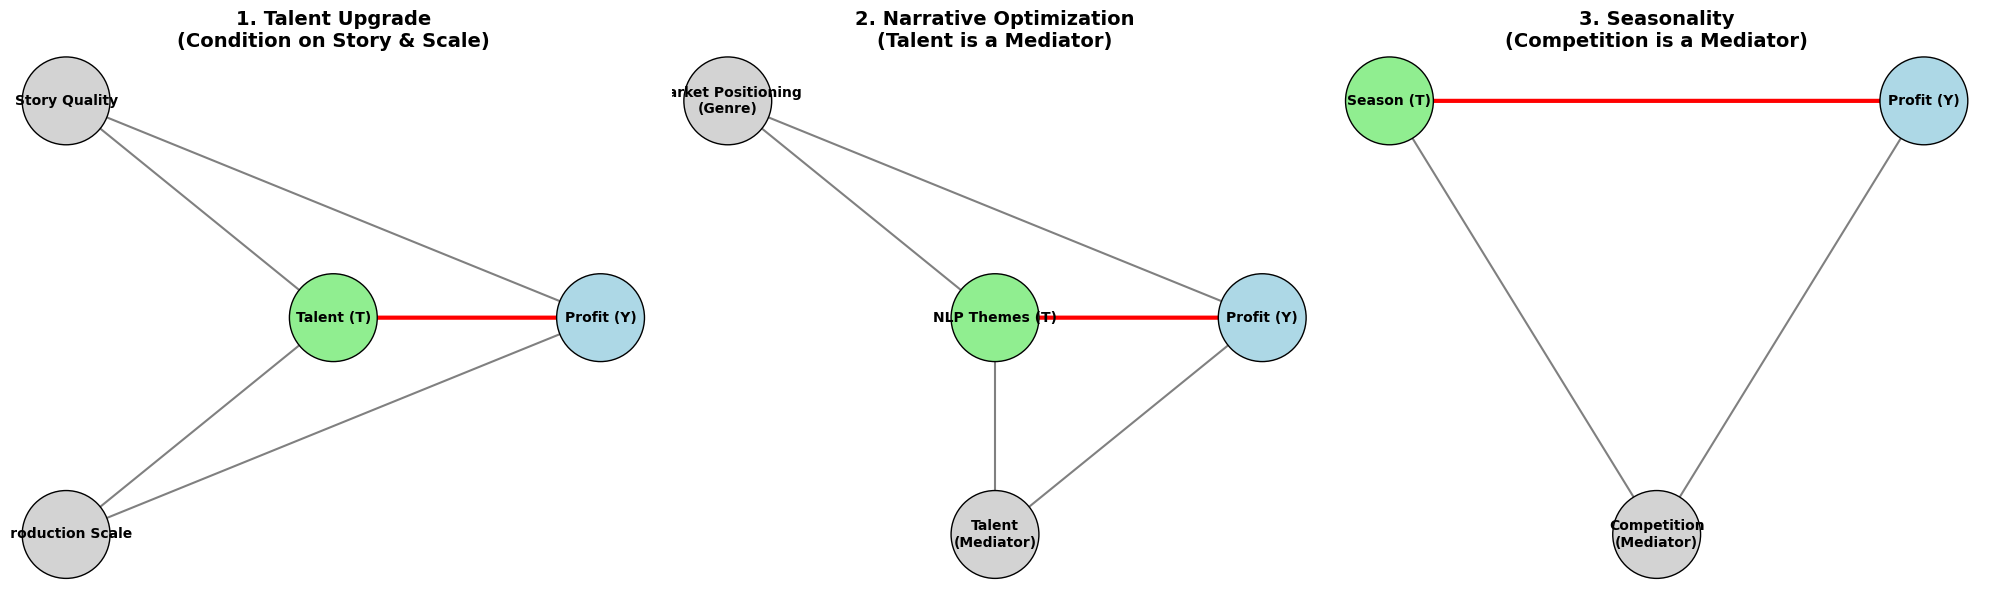

In [16]:
import networkx as nx
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# --- Sub-DAG 1: Talent Treatment ---
G1 = nx.DiGraph()
nodes_1 = (
    "Story Quality",
    "Production Scale",
    "Talent (T)",
    "Profit (Y)"
)
G1.add_nodes_from(nodes_1)

edges_1 = (
    ("Story Quality", "Talent (T)"),
    ("Story Quality", "Profit (Y)"),
    ("Production Scale", "Talent (T)"),
    ("Production Scale", "Profit (Y)"),
    ("Talent (T)", "Profit (Y)")
)
G1.add_edges_from(edges_1)

pos1 = {
    "Story Quality": (0, 2),
    "Production Scale": (0, 0),
    "Talent (T)": (1, 1),
    "Profit (Y)": (2, 1)
}

color_map_1 = ['lightgray', 'lightgray', 'lightgreen', 'lightblue']
nx.draw_networkx_nodes(G1, pos1, ax=axes[0], node_color=color_map_1, node_size=4000, edgecolors='black')
nx.draw_networkx_edges(G1, pos1, ax=axes[0], arrowstyle='-|>', arrowsize=15, edge_color='gray', width=1.5)
nx.draw_networkx_labels(G1, pos1, ax=axes[0], font_size=10, font_weight='bold')

main_path_1 = (("Talent (T)", "Profit (Y)"),)
nx.draw_networkx_edges(G1, pos1, ax=axes[0], edgelist=main_path_1, edge_color='red', width=3, arrowsize=20)
axes[0].set_title("1. Talent Upgrade\n(Condition on Story & Scale)", fontsize=14, fontweight='bold')
axes[0].axis('off')

# --- Sub-DAG 2: Narrative Optimization (NLP Themes) Treatment ---
G2 = nx.DiGraph()
nodes_2 = (
    "Market Positioning\n(Genre)",
    "NLP Themes (T)",
    "Talent\n(Mediator)",
    "Profit (Y)"
)
G2.add_nodes_from(nodes_2)

edges_2 = (
    ("Market Positioning\n(Genre)", "NLP Themes (T)"),
    ("Market Positioning\n(Genre)", "Profit (Y)"),
    ("NLP Themes (T)", "Talent\n(Mediator)"),
    ("Talent\n(Mediator)", "Profit (Y)"),
    ("NLP Themes (T)", "Profit (Y)")
)
G2.add_edges_from(edges_2)

pos2 = {
    "Market Positioning\n(Genre)": (0, 2),
    "NLP Themes (T)": (1, 1),
    "Talent\n(Mediator)": (1, 0),
    "Profit (Y)": (2, 1)
}

color_map_2 = ['lightgray', 'lightgreen', 'lightgray', 'lightblue']
nx.draw_networkx_nodes(G2, pos2, ax=axes[1], node_color=color_map_2, node_size=4000, edgecolors='black')
nx.draw_networkx_edges(G2, pos2, ax=axes[1], arrowstyle='-|>', arrowsize=15, edge_color='gray', width=1.5)
nx.draw_networkx_labels(G2, pos2, ax=axes[1], font_size=10, font_weight='bold')

main_path_2 = (("NLP Themes (T)", "Profit (Y)"),)
nx.draw_networkx_edges(G2, pos2, ax=axes[1], edgelist=main_path_2, edge_color='red', width=3, arrowsize=20)
axes[1].set_title("2. Narrative Optimization\n(Talent is a Mediator)", fontsize=14, fontweight='bold')
axes[1].axis('off')

# --- Sub-DAG 3: Seasonality Treatment ---
G3 = nx.DiGraph()
nodes_3 = (
    "Season (T)",
    "Competition\n(Mediator)",
    "Profit (Y)"
)
G3.add_nodes_from(nodes_3)

edges_3 = (
    ("Season (T)", "Competition\n(Mediator)"),
    ("Competition\n(Mediator)", "Profit (Y)"),
    ("Season (T)", "Profit (Y)")
)
G3.add_edges_from(edges_3)

pos3 = {
    "Season (T)": (0, 1),
    "Competition\n(Mediator)": (1, 0),
    "Profit (Y)": (2, 1)
}

color_map_3 = ['lightgreen', 'lightgray', 'lightblue']
nx.draw_networkx_nodes(G3, pos3, ax=axes[2], node_color=color_map_3, node_size=4000, edgecolors='black')
nx.draw_networkx_edges(G3, pos3, ax=axes[2], arrowstyle='-|>', arrowsize=15, edge_color='gray', width=1.5)
nx.draw_networkx_labels(G3, pos3, ax=axes[2], font_size=10, font_weight='bold')

main_path_3 = (("Season (T)", "Profit (Y)"),)
nx.draw_networkx_edges(G3, pos3, ax=axes[2], edgelist=main_path_3, edge_color='red', width=3, arrowsize=20)
axes[2].set_title("3. Seasonality\n(Competition is a Mediator)", fontsize=14, fontweight='bold')
axes[2].axis('off')

plt.tight_layout()
plt.show()

In [17]:
# ==========================================
# Phase 2 & 3: Feature Engineering & Stratification
# ==========================================
import pandas as pd
import numpy as np

# 1. Feature Engineering for Positivity (Consolidating Sparse NLP Themes)
# We group the specific NLP themes into broader, denser meta-features to avoid empty strata
reliable_themes = ['theme_school', 'theme_secret', 'theme_old', 'theme_years', 'theme_relationship']
risky_themes = ['theme_town', 'theme_drug', 'theme_city', 'theme_police', 'theme_murder']

# Ensure columns exist in the dataframe to avoid KeyErrors
existing_reliable = [c for c in reliable_themes if c in model_df.columns]
existing_risky = [c for c in risky_themes if c in model_df.columns]

# Create meta-features (1 if any of the underlying themes are present in the movie, 0 otherwise)
if existing_reliable:
    model_df['meta_theme_reliable'] = model_df[existing_reliable].max(axis=1)
if existing_risky:
    model_df['meta_theme_risky'] = model_df[existing_risky].max(axis=1)

# 2. Stratification for Talent (Internal Cases)
# We define: 0 = Risky (<65%), 1 = Proven (65-85%), 2 = Elite (>85%)
def assign_tier(win_rate):
    if pd.isna(win_rate):
        return 0  # Default to risky/unknown if missing
    elif win_rate >= 0.85:
        return 2  # Elite
    elif win_rate >= 0.65:
        return 1  # Proven
    else:
        return 0  # Risky

model_df['director_tier'] = model_df['director_win_rate'].apply(assign_tier)

print("Feature engineering complete. Meta-themes created to satisfy Positivity.")
print("Director tiers engineered: 0 (Risky), 1 (Proven), 2 (Elite).")
print("\nDirector Tier Distribution:")
print(model_df['director_tier'].value_counts())

# 3. Stratification for Story Quality (Internal Cases)
model_df['writer_tier'] = model_df['writer_win_rate'].apply(assign_tier)

print("Feature engineering complete. Meta-themes created to satisfy Positivity.")
print("Writer tiers engineered: 0 (Risky), 1 (Proven), 2 (Elite).")
print("\nWriter Tier Distribution:")
print(model_df['writer_tier'].value_counts())

Feature engineering complete. Meta-themes created to satisfy Positivity.
Director tiers engineered: 0 (Risky), 1 (Proven), 2 (Elite).

Director Tier Distribution:
director_tier
0    2032
2    2000
1    1297
Name: count, dtype: int64
Feature engineering complete. Meta-themes created to satisfy Positivity.
Writer tiers engineered: 0 (Risky), 1 (Proven), 2 (Elite).

Writer Tier Distribution:
writer_tier
2    2680
0    1917
1     732
Name: count, dtype: int64


## Phase 3: Average Treament Effects (ATE)

In [ ]:
# Install econml if you haven't already:
!pip install econml

In [20]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.linear_model import LogisticRegression

print("--- Calculating Average Treatment Effects (ATE) ---")

def calculate_ate(df, treatment_col, outcome_col, cols_to_remove_from_covariates_X):
    """Calculates ATE using Standardization and IPTW."""
    temp_df = df.dropna(subset=[treatment_col, outcome_col]).copy()
    T = temp_df[treatment_col]
    Y = temp_df[outcome_col]

    # Create X_base containing only covariates (excluding T, Y, and other specified removals)
    X_base = temp_df.drop(columns=[treatment_col, outcome_col] + cols_to_remove_from_covariates_X, errors='ignore')
    X_base = pd.get_dummies(X_base, drop_first=True)
    X_base.columns = X_base.columns.str.replace(r'[[\]<,]', '', regex=True) # Stripping for XGBoost

    # ---------------------------------------------------------
    # ALGORITHM 1: Standardization (Outcome Regression)
    # ---------------------------------------------------------
    X_for_outcome_model = X_base.copy()
    X_for_outcome_model[treatment_col] = T

    out_model = XGBRegressor(random_state=42, max_depth=4)
    out_model.fit(X_for_outcome_model, Y)

    X_counterfactual_treat = X_base.copy()
    X_counterfactual_treat[treatment_col] = 1

    X_counterfactual_control = X_base.copy()
    X_counterfactual_control[treatment_col] = 0

    Y_hat_1 = out_model.predict(X_counterfactual_treat)
    Y_hat_0 = out_model.predict(X_counterfactual_control)

    ate_standardization = np.mean(Y_hat_1 - Y_hat_0)

# ---------------------------------------------------------
    # ALGORITHM 2: Inverse Probability of Treatment Weighting (IPTW)
    # ---------------------------------------------------------
    ps_model = LogisticRegression(max_iter=2000, random_state=42)
    ps_model.fit(X_base, T)

    e_x = ps_model.predict_proba(X_base)[:, 1]
    e_x = np.clip(e_x, 0.05, 0.95)

    # Use the Hájek Estimator: normalize by the sum of the weights
    weight_1 = T / e_x
    weight_0 = (1 - T) / (1 - e_x)

    term1_hajek = np.sum(weight_1 * Y) / np.sum(weight_1)
    term0_hajek = np.sum(weight_0 * Y) / np.sum(weight_0)

    ate_iptw = term1_hajek - term0_hajek

    return ate_standardization, ate_iptw

# `leakage_and_target` includes:
# ['real_profit', 'real_revenue', 'log_real_revenue', 'ROI', 'score', 'vote_count',
#  'director_win_rate', 'star_win_rate', 'writer_win_rate', 'production_win_rate', 'rating_win_rate', 'is_profitable']

# Define a base list of columns that are *never* to be considered covariates
# These are typically leakage features or the original profit target.
initial_cols_to_remove_from_X = [
    'real_profit', 'real_revenue', 'ROI', 'score', 'vote_count', 'is_profitable'
]

# ---------------------------------------------------------
# Treatment 1: Talent Upgrade (Risky vs. Proven)
#   Treatment: 'director_tier'
#   Outcome: 'log_real_revenue'
#   Additional columns to remove from covariates (X): 'director_win_rate', 'is_top_director'
# ---------------------------------------------------------
df_talent = model_df[model_df['director_tier'].isin([0, 1])].copy() # Fixed isin() error

cols_t1_remove_from_X = list(initial_cols_to_remove_from_X)
# Add original director win rate and its binary proxy to be removed, as they are proxies for 'director_tier'
cols_t1_remove_from_X.append('director_win_rate')
if 'is_top_director' in model_df.columns: # Check if 'is_top_director' exists
    cols_t1_remove_from_X.append('is_top_director')

ate_std_1, ate_iptw_1 = calculate_ate(df_talent, 'director_tier', 'log_real_revenue', cols_t1_remove_from_X)
print("1. Talent Upgrade (Risky -> Proven):")
print(f"   Standardization ATE: {ate_std_1:.4f}")
print(f"   IPTW ATE:            {ate_iptw_1:.4f}\n")

# ---------------------------------------------------------
# Treatment 2: Narrative Optimization (Risky vs. Reliable NLP Themes)
#   Treatment: 'meta_theme_reliable'
#   Outcome: 'log_real_revenue'
#   Additional columns to remove from covariates (X): 'meta_theme_risky', and all talent-related features (as mediators)
# ---------------------------------------------------------
df_theme = model_df[(model_df['meta_theme_reliable'] == 1) ^ (model_df['meta_theme_risky'] == 1)].copy()

cols_t2_remove_from_X = list(initial_cols_to_remove_from_X)
cols_t2_remove_from_X.append('meta_theme_risky') # Remove the counterfactual theme flag

# Talent features are mediators here, so they should be removed from covariates to capture total effect
talent_features_to_exclude = ['director_tier', 'director_win_rate', 'is_top_director', 'writer_tier', 'writer_win_rate', 'star_win_rate']
for feature in talent_features_to_exclude:
    if feature in model_df.columns and feature not in cols_t2_remove_from_X:
        cols_t2_remove_from_X.append(feature)

ate_std_2, ate_iptw_2 = calculate_ate(df_theme, 'meta_theme_reliable', 'log_real_revenue', cols_t2_remove_from_X)
print("2. Narrative Optimization (Risky Theme -> Reliable Theme):")
print(f"   Standardization ATE: {ate_std_2:.4f}")
print(f"   IPTW ATE:            {ate_iptw_2:.4f}\n")


# ---------------------------------------------------------
# Treatment 3: Seasonality (Off-Season vs. Blockbuster)
#   Treatment: 'is_blockbuster_season'
#   Outcome: 'log_real_revenue'
#   Additional columns to remove from covariates (X): None specific to seasonality for X_base
# ---------------------------------------------------------
if 'is_blockbuster_season' in model_df.columns:
    cols_t3_remove_from_X = list(initial_cols_to_remove_from_X)
    ate_std_3, ate_iptw_3 = calculate_ate(model_df, 'is_blockbuster_season', 'log_real_revenue', cols_t3_remove_from_X)
    print("3. Seasonality (Off-Season -> Blockbuster):")
    print(f"   Standardization ATE: {ate_std_3:.4f}")
    print(f"   IPTW ATE:            {ate_iptw_3:.4f}")
else:
    print("3. Seasonality: 'is_blockbuster_season' not found.")

--- Calculating Average Treatment Effects (ATE) ---


TypeError: cannot unpack non-iterable NoneType object

In [25]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.linear_model import LogisticRegression

print("--- Calculating Average Treatment Effects (ATE) ---")

def calculate_ate(df, treatment_col, outcome_col, cols_to_remove_from_covariates_X):
    """Calculates ATE using Standardization and IPTW."""
    temp_df = df.dropna(subset=[treatment_col, outcome_col]).copy()
    T = temp_df[treatment_col]
    Y = temp_df[outcome_col]

    # Create X_base containing only covariates
    X_base = temp_df.drop(columns=[treatment_col, outcome_col] + cols_to_remove_from_covariates_X, errors='ignore')
    X_base = pd.get_dummies(X_base, drop_first=True)
    X_base.columns = X_base.columns.str.replace(r'[[\]<,]', '', regex=True) # Stripping for XGBoost

    # ---------------------------------------------------------
    # ALGORITHM 1: Standardization (Outcome Regression)
    # ---------------------------------------------------------
    X_for_outcome_model = X_base.copy()
    X_for_outcome_model[treatment_col] = T

    out_model = XGBRegressor(random_state=42, max_depth=4)
    out_model.fit(X_for_outcome_model, Y)

    X_counterfactual_treat = X_base.copy()
    X_counterfactual_treat[treatment_col] = 1

    X_counterfactual_control = X_base.copy()
    X_counterfactual_control[treatment_col] = 0

    Y_hat_1 = out_model.predict(X_counterfactual_treat)
    Y_hat_0 = out_model.predict(X_counterfactual_control)

    ate_standardization = np.mean(Y_hat_1 - Y_hat_0)

    # ---------------------------------------------------------
    # ALGORITHM 2: Inverse Probability of Treatment Weighting (IPTW)
    # ---------------------------------------------------------
    ps_model = LogisticRegression(max_iter=2000, random_state=42)
    ps_model.fit(X_base, T)

    e_x = ps_model.predict_proba(X_base)[:, 1]
    e_x = np.clip(e_x, 0.05, 0.95)

    # Use the Hájek Estimator: normalize by the sum of the weights
    weight_1 = T / e_x
    weight_0 = (1 - T) / (1 - e_x)

    term1_hajek = np.sum(weight_1 * Y) / np.sum(weight_1)
    term0_hajek = np.sum(weight_0 * Y) / np.sum(weight_0)

    ate_iptw = term1_hajek - term0_hajek

    # THIS IS THE MISSING LINE THAT CAUSED THE ERROR:
    return ate_standardization, ate_iptw


# Define a base list of columns that are *never* to be considered covariates
initial_cols_to_remove_from_X = ['movie_id', 'real_budget', 'real_revenue', 'real_profit',
       'is_profitable', 'ROI', 'log_real_revenue','vote_count', 'score']

# ---------------------------------------------------------
# Treatment 1: Talent Upgrade (Risky vs. Proven)
# ---------------------------------------------------------
df_talent = model_df[model_df['director_tier'].isin([0, 1])].copy()

cols_t1_remove_from_X = list(initial_cols_to_remove_from_X)
cols_t1_remove_from_X.append('director_win_rate')
if 'is_top_director' in model_df.columns:
    cols_t1_remove_from_X.append('is_top_director')

ate_std_1, ate_iptw_1 = calculate_ate(df_talent, 'director_tier', 'log_real_revenue', cols_t1_remove_from_X)
print("1. Talent Upgrade (Risky -> Proven):")
print(f"   Standardization ATE: {ate_std_1:.4f}")
print(f"   IPTW ATE:            {ate_iptw_1:.4f}\n")

# ---------------------------------------------------------
# Treatment 2: Narrative Optimization (Risky vs. Reliable NLP Themes)
# ---------------------------------------------------------
df_theme = model_df[(model_df['meta_theme_reliable'] == 1) ^ (model_df['meta_theme_risky'] == 1)].copy()

cols_t2_remove_from_X = list(initial_cols_to_remove_from_X)
cols_t2_remove_from_X.append('meta_theme_risky')

# Talent features are mediators here, so they should be removed from covariates
talent_features_to_exclude = ['director_tier', 'director_win_rate', 'is_top_director', 'writer_tier', 'writer_win_rate', 'star_win_rate']
for feature in talent_features_to_exclude:
    if feature in model_df.columns and feature not in cols_t2_remove_from_X:
        cols_t2_remove_from_X.append(feature)

ate_std_2, ate_iptw_2 = calculate_ate(df_theme, 'meta_theme_reliable', 'log_real_revenue', cols_t2_remove_from_X)
print("2. Narrative Optimization (Risky Theme -> Reliable Theme):")
print(f"   Standardization ATE: {ate_std_2:.4f}")
print(f"   IPTW ATE:            {ate_iptw_2:.4f}\n")

# ---------------------------------------------------------
# Treatment 3: Seasonality (Off-Season vs. Blockbuster)
# ---------------------------------------------------------
if 'is_blockbuster_season' in model_df.columns:
    cols_t3_remove_from_X = list(initial_cols_to_remove_from_X)
    ate_std_3, ate_iptw_3 = calculate_ate(model_df, 'is_blockbuster_season', 'log_real_revenue', cols_t3_remove_from_X)
    print("3. Seasonality (Off-Season -> Blockbuster):")
    print(f"   Standardization ATE: {ate_std_3:.4f}")
    print(f"   IPTW ATE:            {ate_iptw_3:.4f}")
else:
    print("3. Seasonality: 'is_blockbuster_season' not found.")

--- Calculating Average Treatment Effects (ATE) ---
1. Talent Upgrade (Risky -> Proven):
   Standardization ATE: 0.2563
   IPTW ATE:            1.2570



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


2. Narrative Optimization (Risky Theme -> Reliable Theme):
   Standardization ATE: 0.0245
   IPTW ATE:            0.4636

3. Seasonality (Off-Season -> Blockbuster):
   Standardization ATE: 0.1204
   IPTW ATE:            0.8243
